## <em> Regularization, and Logistic & Softmax Regression</em>
## <em> with the MNIST dataset</em>

### Imports

In [2]:
import numpy as np
from scipy.integrate import quad
#For plotting
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

***

We generalize logistic regression to the case of multiple categories which is called Softmax regression. A paradigmatic example of SoftMax regression is the MNIST classification problem. The goal is to find a statistical model which recognizes the ten handwritten digits. There are numerous practical applications of such a task, pretty much anywhere one can imagine dealing with large quantities of numbers.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state

# Load MNIST data
X = np.loadtxt("./mnistX.dat")
Y = np.loadtxt("./mnistY.dat")

In [4]:
np.shape(X)

(3800, 784)

"$X$" contains information about the given MNIST digits. We have a 28x28 pixel grid, so each image is a vector of length 784; we have 3800 images (digits), so $X$ is a 3800x784 matrix. "$Y$" is a label (0-9; the category to which each image belongs) vector of length 3800.

<span style="color:blue"> <i> Randomly shuffle data and split them into training and test samples using train_test_split. Let train_size = 0.8. Print the dimension of training and test samples. </i></span> <br>


In [6]:
# shuffle data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X,Y = unison_shuffled_copies(X, Y)

# Another way of acheiving the same shuffle:
"""
random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0]) 
X = X[permutation]
Y = Y[permutation]
X = X.reshape((X.shape[0], -1))
"""

# pick training and test data sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, train_size = 0.8)


print('Train Set:', np.shape(X_train), np.shape(Y_train) )
print('Test Set:', np.shape(X_test), np.shape(Y_test) )

Train Set: (3040, 784) (3040,)
Test Set: (760, 784) (760,)


<span style="color:blue"> <i> Choose any five images and show what the images look like. Print the corresponding labels. </i></span> <br>

Note: each image is a vector of length 784. So reshape it into a 28x28 matrix.<br>
$\ \ $ X_0 = X_train[0]<br>
$\ \ $  X_0 = X_0.reshape((28, 28))<br>
Then, make a plot using imshow.<br>
$\ \ $  plt.imshow(X_0, cmap=plt.cm.gray)

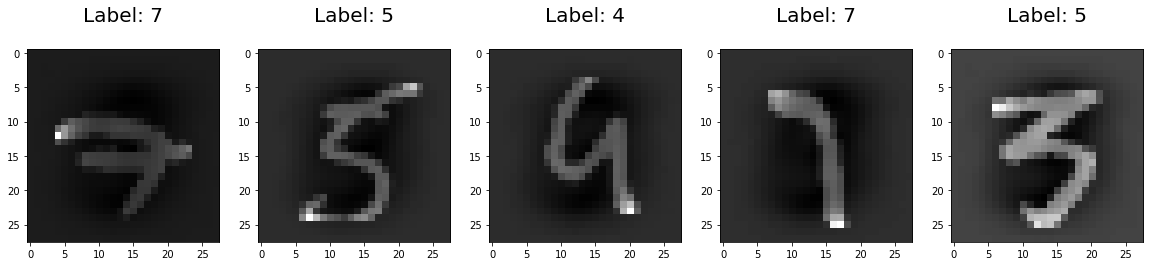

In [10]:
plt.figure(figsize=(20,4))
for index, (image, label) in enumerate(zip(X_train[6:11], Y_train[6:11])):
    plt.subplot(1, 5, index + 1) 
    plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray) 
    plt.title('Label: %i\n' % label, fontsize = 20)

Now, perform the logistic regression in the following steps:

1. Scale data to have zero mean and unit variance (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) <br>
  scaler = StandardScaler() <br>
  X_train = scaler.fit_transform(X_train) <br>
  X_test = scaler.transform(X_test) <br>
2. Make an instance of the model using LogisticRegression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Try "liblinear" and "sag" optimization algorithms.<br>
  $\textbf{liblinear}$: Use solver='liblinear' and use L1 norm in the penalization (penalty='l1'). Also set C=1e5 and tol=.3<br>
  $\textbf{sag}$: Use solver='sag' and use L2 norm in the penalization (penalty='l2'). Also set C=1e5 and tol=.1<br>
  e.g. model = LogisticRegression(...) <br>
3. Train the model on the data <br>
  e.g. model.fit(training X sample, training Y samples)<br>
4. Predict the labels of test data.<br>
  e.g. digit_predict = model.predict(test X samples)<br>
5. Compute the accuracy<br>
  e.g. model.score(test X samples, test Y samples)<br>
  
<span style="color:blue"> <i> Using both liblinear and sag solvers, we compute the accuracy of the test samples. We also measure the training time (how long it takes to train the model on the data) using time.time().  </i></span> <br>


In [11]:
import time

scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 

# liblinear
model_lib = LogisticRegression(solver='liblinear', penalty='l1', C=1e5, tol=0.3)
t0 = time.time()
model_lib.fit(X_train, Y_train)
run_time = time.time() - t0
digit_predict_lib = model_lib.predict(X_test)
score = model_lib.score(X_test, Y_test)


print('liblinear:')
print('Run time: %.3f s' % run_time)
print('accuracy: %.3f' % score)

# sag
model_sag = LogisticRegression(solver='sag', penalty='l2', C=1e5, tol=0.1)
t0 = time.time()
model_sag.fit(X_train, Y_train)
run_time = time.time() - t0
digit_predict_sag = model_sag.predict(X_test)
score = model_sag.score(X_test, Y_test)

print('sag:')
print('Run time: %.3f s' % run_time)
print('accuracy: %.3f' % score)

liblinear:
Run time: 2.952 s
accuracy: 0.863
sag:
Run time: 0.256 s
accuracy: 0.876


<span style="color:blue"> <i> Choose any 15 images and show what the images look like. What are the predicted labels corresponding to them? Take a look at the misclassified samples using the sag solver. </i></span> <br>


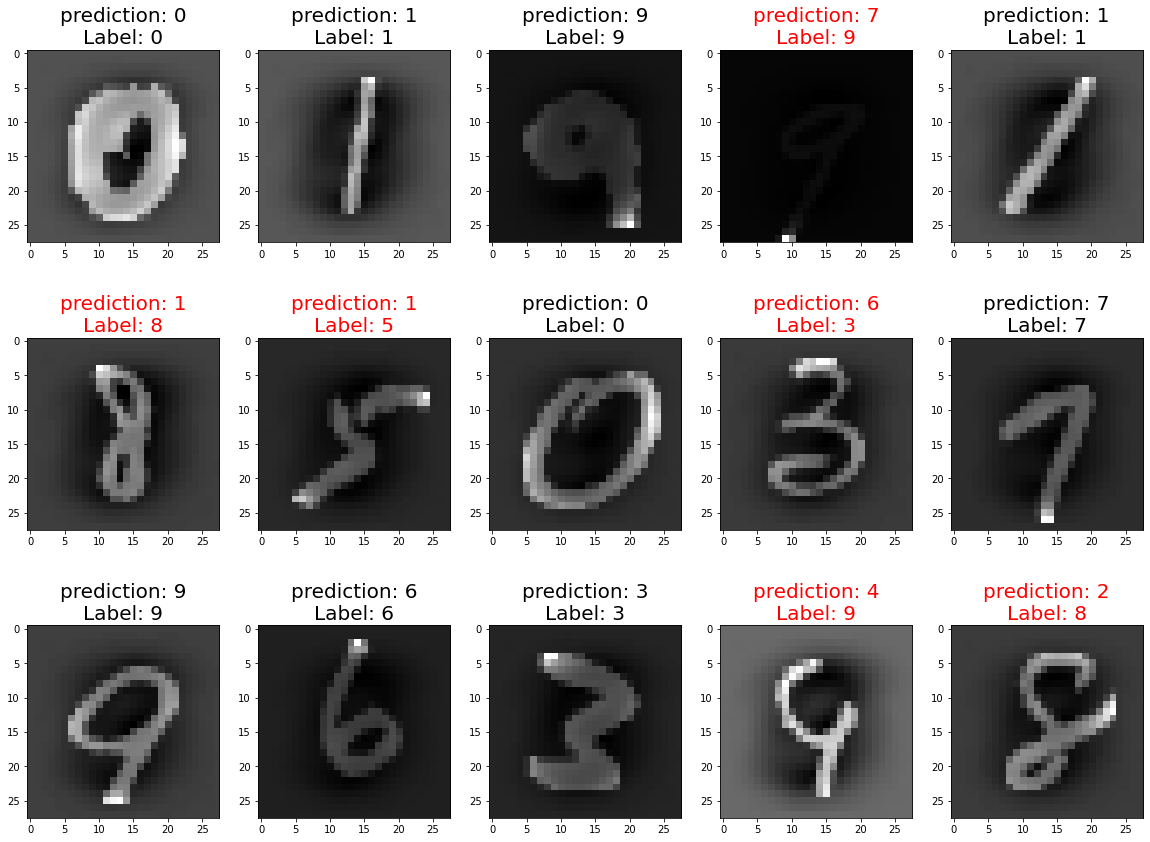

In [32]:
predict = model_sag.predict(X_test)

plt.figure(figsize=(20,15))
for index, (image, pred) in enumerate(zip(X_test[0:15], predict[0:15])):
    plt.subplot(3, 5, index + 1) 
    plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray) 
    if pred != Y_test[index]:
        plt.title('prediction: %i\n' % pred + 'Label: %i' % Y_test[index], color='red', fontsize = 20)
    plt.title('prediction: %i\n' % pred + 'Label: %i' % Y_test[index], fontsize = 20)

<span style="color:blue"> <i> Choose any 15 images and show what the images look like. What are the predicted labels corresponding to them? Take a look at the misclassified samples using the liblinear solver. </i></span> <br>



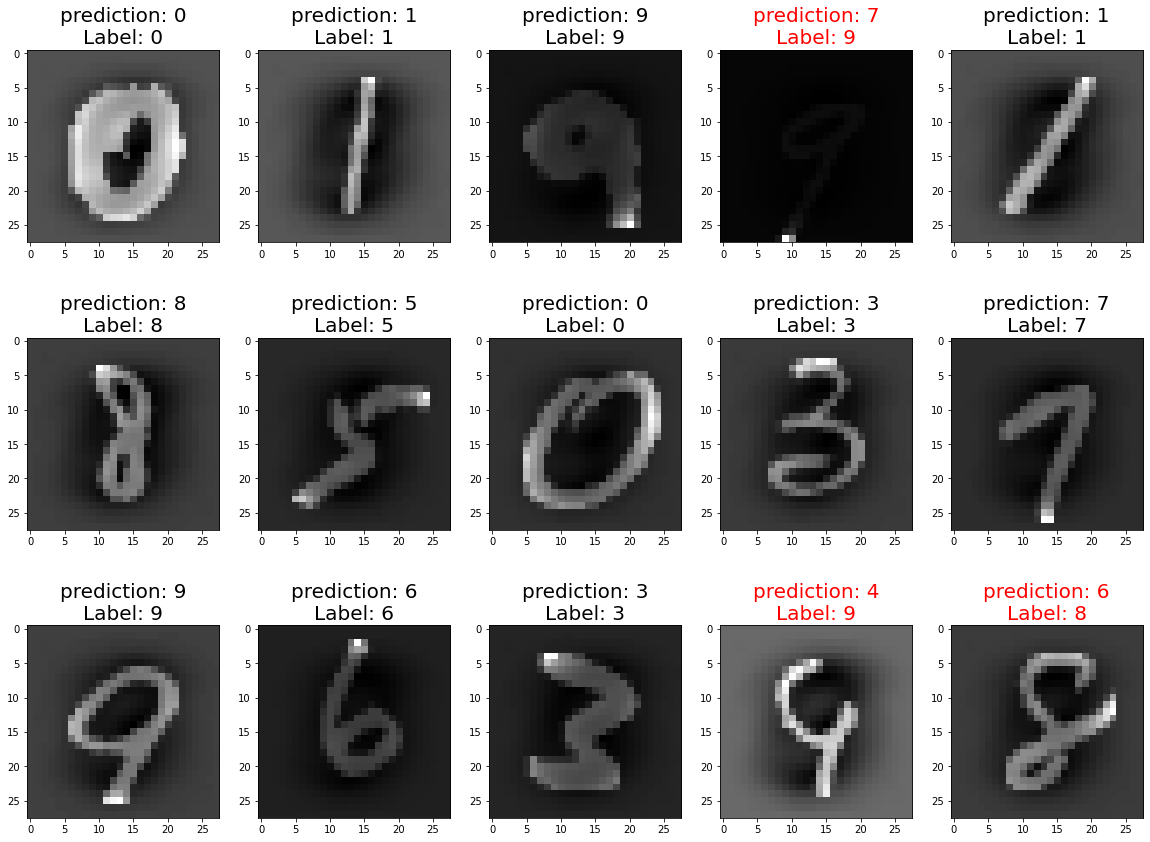

In [58]:
predict = model_lib.predict(X_test)

plt.figure(figsize=(20,15))
for index, (image, pred) in enumerate(zip(X_test[0:15], predict[0:15])):
    plt.subplot(3, 5, index + 1) 
    plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray) 
    if pred != Y_test[index]:
        plt.title('prediction: %i\n' % pred + 'Label: %i' % Y_test[index], color='red', fontsize = 20)
    plt.title('prediction: %i\n' % pred + 'Label: %i' % Y_test[index], fontsize = 20)

Here, we have 10 classes and 784 features. Using "coef_", we can get the coefficient of the features in the decision function. These are basically classication "weights." 

<span style="color:blue"> <i> Obtain the coefficient of the features for the model using the sag solver. (coef = sag.coef_) This is a 10x784 matrix. (number of classes x number of features) Reshape it into 28x28 and make a plot for each class. How do they look? Can you recognize the digits? </i></span> <br>


In [48]:
coef = model_sag.coef_ 
coef.shape

(10, 784)

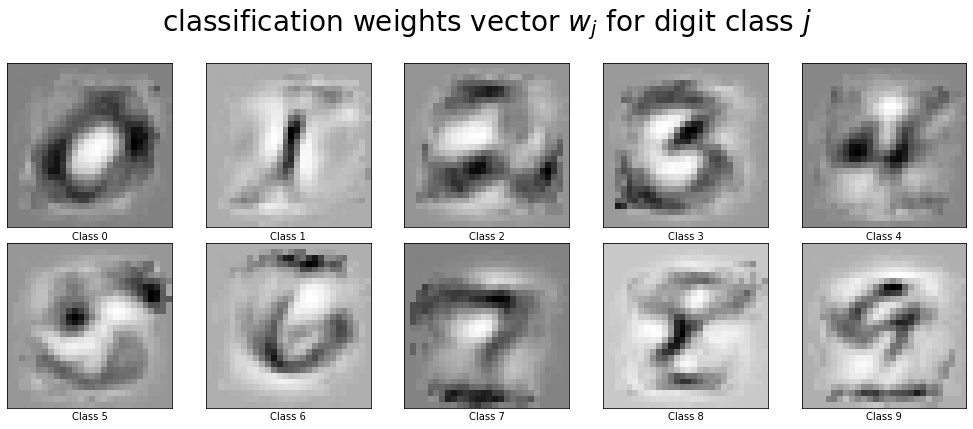

In [57]:
# plot weights vs the pixel position 
plt.figure(figsize=(14, 6)) 

for i in range(10):
    plt.subplot(2, 5, i + 1) 
    plt.imshow(coef[i].reshape(28, 28), cmap=plt.cm.Greys) 
    plt.xticks(())
    plt.yticks(())
    plt.xlabel('Class %i' % i)
    
plt.suptitle('classification weights vector $w_j$ for digit class $j$', fontsize=28) 
plt.tight_layout(pad=1.5)
plt.show()

***